<a href="https://colab.research.google.com/github/salianvikram/VTU-MAJOR-PROJECT-27/blob/main/LSTM_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.
TensorFlow version: 2.20.0


/tmp/ipykernel_810/2223956870.py:55: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(



Dataset loaded successfully.
Dataset Shape: (1048575, 16)

First 5 rows:
  StationId          Datetime  PM2.5    PM10    NO    NO2    NOx    NH3   CO  \
0     AP001  24-11-2017 17:00  60.50   98.00  2.35  30.80  18.25   8.50  0.1   
1     AP001  24-11-2017 18:00  65.50  111.25  2.70  24.20  15.07   9.77  0.1   
2     AP001  24-11-2017 19:00  80.00  132.00  2.10  25.18  15.15  12.02  0.1   
3     AP001  24-11-2017 20:00  81.50  133.25  1.95  16.25  10.23  11.58  0.1   
4     AP001  24-11-2017 21:00  75.25  116.00  1.43  17.48  10.43  12.03  0.1   

     SO2      O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  11.85  126.40      0.1     6.10    0.10  NaN        NaN  
1  13.17  117.12      0.1     6.25    0.15  NaN        NaN  
2  12.08   98.98      0.2     5.98    0.18  NaN        NaN  
3  10.47  112.20      0.2     6.72    0.10  NaN        NaN  
4   9.12  106.35      0.2     5.75    0.08  NaN        NaN  

Columns available:
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NO

/tmp/ipykernel_810/2223956870.py:375: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[
/tmp/ipykernel_810/2223956870.py:397: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[
/tmp/ipykernel_810/2223956870.py:419: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[
/tmp/ipykernel_810/2223956870.py:375:


Rolling pollutant features created.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,881 (245.63 KB)

 Trainable params: 62,881 (245.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.1627 - mae: 0.2700 - val_loss: 0.0776 - val_mae: 0.1827 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0633 - mae: 0.1737 - val_loss: 0.0650 - val_mae: 0.1655 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0516 - mae: 0.1553 - val_loss: 0.0588 - val_mae: 0.1587 - learning_rate: 0.0010
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0454 - mae: 0.1457 - val_loss: 0.0579 - val_mae: 0.1621 - learning_rate: 0.0010
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - loss: 0.0400 - mae: 0.1367 - val_loss: 0.0518 - val_mae: 0.1440 - learning_rate: 0.0010
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0369 - mae: 0.1313 - val_loss: 0.0571 - val_mae: 0.1677 - learning_rate: 0.0010
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0355 - mae: 0.1265 - val_loss: 0.0541 - val_mae: 0.1567 - lea

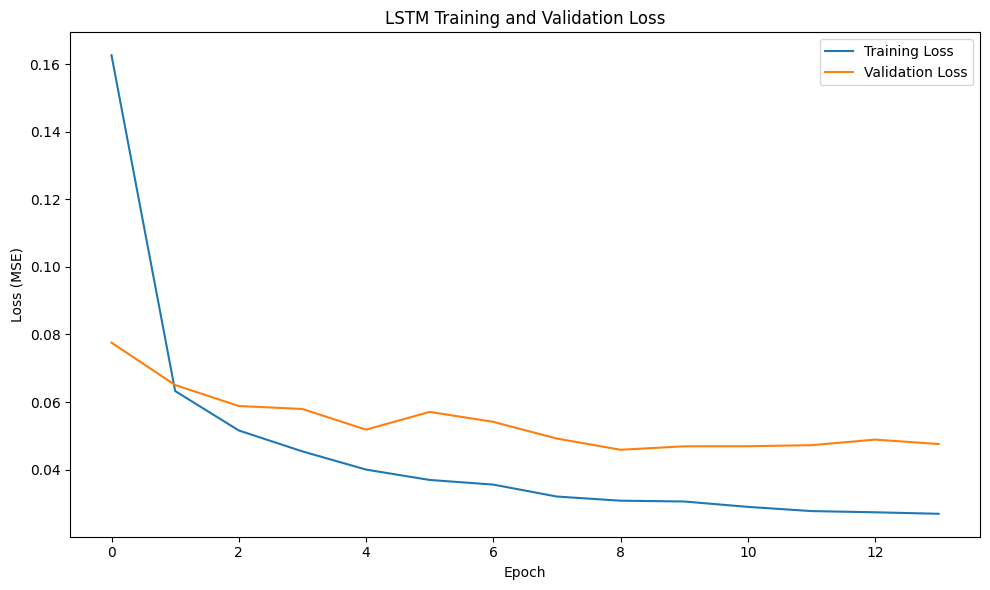

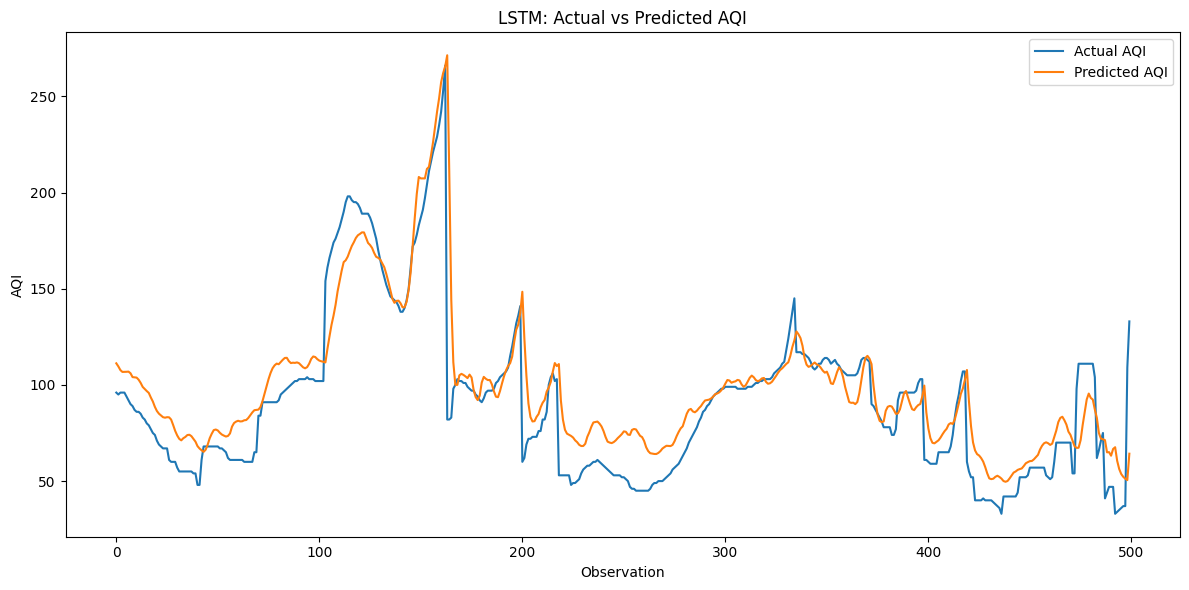


LSTM model and scalers saved successfully.


FINAL LSTM MODEL SUMMARY
Algorithm        : LSTM Neural Network
Prediction        : Next-Hour AQI
Pollutants        : All available pollutants
Lag periods       : 1, 3, 6, 12, 24 hours
Rolling periods   : 3, 6, 24 hours
Sequence length   : 24 hours
Training period   : 2015 - 2019
Testing period    : 2020
MAE               : 16.21
RMSE              : 25.68
R²                : 0.8941


In [2]:
# ============================================================
# AIR QUALITY INDEX (AQI) PREDICTION
# LSTM MODEL
# ALL POLLUTANTS + TIME FEATURES + LAG + ROLLING FEATURES
# NEXT-HOUR AQI FORECASTING
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("Libraries imported successfully.")

print(
    "TensorFlow version:",
    tf.__version__
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

file_name = "station_hour.csv"

df = pd.read_csv(
    file_name
)

print("\nDataset loaded successfully.")

print(
    "Dataset Shape:",
    df.shape
)

print("\nFirst 5 rows:")

print(
    df.head()
)


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
)

print("\nColumns available:")

print(
    df.columns.tolist()
)


# ============================================================
# 4. CONVERT DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(

    df['Datetime'],

    format='%d-%m-%Y %H:%M',

    errors='coerce'

)

df = df.dropna(
    subset=['Datetime']
)

print(
    "\nDatetime conversion completed."
)


# ============================================================
# 5. SORT DATA CHRONOLOGICALLY
# ============================================================

df = df.sort_values(

    by=[
        'StationId',
        'Datetime'
    ]

).reset_index(
    drop=True
)

print(
    "\nDataset sorted by StationId and Datetime."
)


# ============================================================
# 6. DEFINE POLLUTANT FEATURES
# ============================================================

pollutant_features = [

    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'

]


# Keep only columns present in dataset

pollutant_features = [

    col

    for col in pollutant_features

    if col in df.columns

]


print(
    "\nPollutant features used:"
)

print(
    pollutant_features
)


# ============================================================
# 7. CONVERT POLLUTANTS AND AQI TO NUMERIC
# ============================================================

for col in pollutant_features:

    df[col] = pd.to_numeric(

        df[col],

        errors='coerce'

    )


df['AQI'] = pd.to_numeric(

    df['AQI'],

    errors='coerce'

)


print(
    "\nPollutant and AQI columns converted to numeric."
)


# ============================================================
# 8. CREATE TIME FEATURES
# ============================================================

df['Hour'] = (
    df['Datetime'].dt.hour
)

df['Day'] = (
    df['Datetime'].dt.day
)

df['Month'] = (
    df['Datetime'].dt.month
)

df['DayOfWeek'] = (
    df['Datetime'].dt.dayofweek
)

df['DayOfYear'] = (
    df['Datetime'].dt.dayofyear
)

df['WeekOfYear'] = (

    df['Datetime']
    .dt.isocalendar()
    .week
    .astype(int)

)

df['Year'] = (
    df['Datetime'].dt.year
)

df['IsWeekend'] = (

    df['DayOfWeek'] >= 5

).astype(int)


print(
    "\nTime features created."
)


# ============================================================
# 9. CREATE CYCLIC TIME FEATURES
# ============================================================

df['Hour_Sin'] = np.sin(

    2 * np.pi *
    df['Hour'] / 24

)

df['Hour_Cos'] = np.cos(

    2 * np.pi *
    df['Hour'] / 24

)


df['Month_Sin'] = np.sin(

    2 * np.pi *
    df['Month'] / 12

)

df['Month_Cos'] = np.cos(

    2 * np.pi *
    df['Month'] / 12

)


df['DayOfWeek_Sin'] = np.sin(

    2 * np.pi *
    df['DayOfWeek'] / 7

)

df['DayOfWeek_Cos'] = np.cos(

    2 * np.pi *
    df['DayOfWeek'] / 7

)


print(
    "\nCyclic time features created."
)


# ============================================================
# 10. CREATE POLLUTANT LAG FEATURES
# ============================================================

lag_hours = [

    1,
    3,
    6,
    12,
    24

]


for col in pollutant_features:

    for lag in lag_hours:

        df[
            f'{col}_lag_{lag}'
        ] = (

            df
            .groupby('StationId')[col]
            .shift(lag)

        )


print(
    "\nPollutant lag features created."
)


# ============================================================
# 11. CREATE AQI LAG FEATURES
# ============================================================

for lag in lag_hours:

    df[
        f'AQI_lag_{lag}'
    ] = (

        df
        .groupby('StationId')['AQI']
        .shift(lag)

    )


print(
    "\nAQI lag features created."
)


# ============================================================
# 12. CREATE ROLLING POLLUTANT FEATURES
# ============================================================

for col in pollutant_features:

    # --------------------------------------------------------
    # Previous 3-hour average
    # --------------------------------------------------------

    df[
        f'{col}_rolling_3'
    ] = (

        df
        .groupby('StationId')[col]
        .transform(

            lambda x:
            x.shift(1)
            .rolling(3)
            .mean()

        )

    )


    # --------------------------------------------------------
    # Previous 6-hour average
    # --------------------------------------------------------

    df[
        f'{col}_rolling_6'
    ] = (

        df
        .groupby('StationId')[col]
        .transform(

            lambda x:
            x.shift(1)
            .rolling(6)
            .mean()

        )

    )


    # --------------------------------------------------------
    # Previous 24-hour average
    # --------------------------------------------------------

    df[
        f'{col}_rolling_24'
    ] = (

        df
        .groupby('StationId')[col]
        .transform(

            lambda x:
            x.shift(1)
            .rolling(24)
            .mean()

        )

    )


print(
    "\nRolling pollutant features created."
)


# ============================================================
# 13. CREATE ROLLING AQI FEATURES
# ============================================================

df['AQI_rolling_3'] = (

    df
    .groupby('StationId')['AQI']
    .transform(

        lambda x:
        x.shift(1)
        .rolling(3)
        .mean()

    )

)


df['AQI_rolling_6'] = (

    df
    .groupby('StationId')['AQI']
    .transform(

        lambda x:
        x.shift(1)
        .rolling(6)
        .mean()

    )

)


df['AQI_rolling_24'] = (

    df
    .groupby('StationId')['AQI']
    .transform(

        lambda x:
        x.shift(1)
        .rolling(24)
        .mean()

    )

)


print(
    "\nRolling AQI features created."
)


# ============================================================
# 14. CREATE NEXT-HOUR AQI TARGET
# ============================================================

df['AQI_Next_Hour'] = (

    df
    .groupby('StationId')['AQI']
    .shift(-1)

)


print(
    "\nNext-hour AQI target created."
)


# ============================================================
# 15. DEFINE TIME FEATURES
# ============================================================

time_features = [

    'Hour',
    'Day',
    'Month',
    'DayOfWeek',
    'DayOfYear',
    'WeekOfYear',
    'Year',
    'IsWeekend',

    'Hour_Sin',
    'Hour_Cos',

    'Month_Sin',
    'Month_Cos',

    'DayOfWeek_Sin',
    'DayOfWeek_Cos'

]


# ============================================================
# 16. DEFINE LAG FEATURES
# ============================================================

lag_features = []


for col in pollutant_features:

    for lag in lag_hours:

        lag_features.append(

            f'{col}_lag_{lag}'

        )


# ============================================================
# 17. DEFINE AQI LAG FEATURES
# ============================================================

aqi_lag_features = [

    f'AQI_lag_{lag}'

    for lag in lag_hours

]


# ============================================================
# 18. DEFINE ROLLING FEATURES
# ============================================================

rolling_features = []


for col in pollutant_features:

    rolling_features.extend([

        f'{col}_rolling_3',

        f'{col}_rolling_6',

        f'{col}_rolling_24'

    ])


# ============================================================
# 19. DEFINE AQI ROLLING FEATURES
# ============================================================

aqi_rolling_features = [

    'AQI_rolling_3',

    'AQI_rolling_6',

    'AQI_rolling_24'

]


# ============================================================
# 20. COMBINE ALL FEATURES
# ============================================================

features = (

    pollutant_features

    + time_features

    + lag_features

    + aqi_lag_features

    + rolling_features

    + aqi_rolling_features

)


print(
    "\nTotal number of features:",
    len(features)
)


# ============================================================
# 21. REMOVE MISSING VALUES
# ============================================================

df_model = df.dropna(

    subset=
    features
    + ['AQI_Next_Hour']

).copy()


print(
    "\nRows available for modelling:",
    len(df_model)
)


# ============================================================
# 22. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Training:
# 2015 - 2019
#
# Testing:
# 2020

train_df = df_model[

    df_model['Year'] < 2020

].copy()


test_df = df_model[

    df_model['Year'] >= 2020

].copy()


print(
    "\nTraining rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)


# ============================================================
# 23. PREPARE TRAINING FEATURES
# ============================================================

X_train_raw = (

    train_df[features]
    .values

)

y_train_raw = (

    train_df['AQI_Next_Hour']
    .values

)


# ============================================================
# 24. PREPARE TESTING FEATURES
# ============================================================

X_test_raw = (

    test_df[features]
    .values

)

y_test_raw = (

    test_df['AQI_Next_Hour']
    .values

)


print(
    "\nRaw training shape:",
    X_train_raw.shape
)

print(
    "Raw testing shape:",
    X_test_raw.shape
)


# ============================================================
# 25. FEATURE SCALING
# ============================================================

# LSTM performs much better when numerical features
# are scaled.

scaler_X = StandardScaler()

X_train_scaled = (

    scaler_X
    .fit_transform(
        X_train_raw
    )

)


X_test_scaled = (

    scaler_X
    .transform(
        X_test_raw
    )

)


# ============================================================
# 26. SCALE TARGET VARIABLE
# ============================================================

scaler_y = StandardScaler()


y_train_scaled = (

    scaler_y
    .fit_transform(

        y_train_raw
        .reshape(-1, 1)

    )
    .flatten()

)


print(
    "\nFeature and target scaling completed."
)


# ============================================================
# 27. CREATE LSTM SEQUENCES
# ============================================================

# Number of previous observations used
# to predict the next-hour AQI.

SEQUENCE_LENGTH = 24


def create_sequences(
    X,
    y,
    sequence_length
):

    X_sequences = []

    y_sequences = []


    for i in range(

        sequence_length,
        len(X)

    ):

        X_sequences.append(

            X[
                i-sequence_length:i
            ]

        )

        y_sequences.append(

            y[i]

        )


    return (

        np.array(X_sequences),

        np.array(y_sequences)

    )


# ============================================================
# 28. CREATE TRAINING SEQUENCES
# ============================================================

X_train_seq, y_train_seq = (

    create_sequences(

        X_train_scaled,

        y_train_scaled,

        SEQUENCE_LENGTH

    )

)


# ============================================================
# 29. CREATE TESTING SEQUENCES
# ============================================================

X_test_seq, y_test_seq = (

    create_sequences(

        X_test_scaled,

        # Target does not need scaling again
        # because y_test_scaled is not available
        # from the training scaler.

        scaler_y.transform(
            y_test_raw.reshape(-1, 1)
        ).flatten(),

        SEQUENCE_LENGTH

    )

)


print(
    "\nLSTM sequence creation completed."
)

print(
    "X_train sequence shape:",
    X_train_seq.shape
)

print(
    "y_train sequence shape:",
    y_train_seq.shape
)

print(
    "X_test sequence shape:",
    X_test_seq.shape
)

print(
    "y_test sequence shape:",
    y_test_seq.shape
)


# ============================================================
# 30. BUILD LSTM MODEL
# ============================================================

model = Sequential()


# ------------------------------------------------------------
# First LSTM layer
# ------------------------------------------------------------

model.add(

    LSTM(

        64,

        return_sequences=True,

        input_shape=(

            X_train_seq.shape[1],

            X_train_seq.shape[2]

        )

    )

)


# ------------------------------------------------------------
# Dropout
# ------------------------------------------------------------

model.add(

    Dropout(
        0.2
    )

)


# ------------------------------------------------------------
# Second LSTM layer
# ------------------------------------------------------------

model.add(

    LSTM(
        32
    )

)


# ------------------------------------------------------------
# Dropout
# ------------------------------------------------------------

model.add(

    Dropout(
        0.2
    )

)


# ------------------------------------------------------------
# Dense layer
# ------------------------------------------------------------

model.add(

    Dense(
        16,
        activation='relu'
    )

)


# ------------------------------------------------------------
# Output layer
# ------------------------------------------------------------

model.add(

    Dense(
        1
    )

)


# ============================================================
# 31. COMPILE LSTM MODEL
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='mse',

    metrics=['mae']

)


print(
    "\nLSTM model created successfully."
)

model.summary()


# ============================================================
# 32. DEFINE CALLBACKS
# ============================================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)


reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    min_lr=0.00001

)


# ============================================================
# 33. TRAIN LSTM MODEL
# ============================================================

print(
    "\nTraining LSTM model..."
)


history = model.fit(

    X_train_seq,

    y_train_seq,

    epochs=30,

    batch_size=256,

    validation_split=0.1,

    callbacks=[

        early_stopping,

        reduce_lr

    ],

    verbose=1

)


print(
    "\nLSTM training completed."
)


# ============================================================
# 34. MAKE TEST PREDICTIONS
# ============================================================

y_pred_scaled = model.predict(

    X_test_seq,

    verbose=1

)


# ============================================================
# 35. CONVERT PREDICTIONS BACK TO ORIGINAL AQI SCALE
# ============================================================

y_pred = scaler_y.inverse_transform(

    y_pred_scaled

).flatten()


y_test_actual = scaler_y.inverse_transform(

    y_test_seq.reshape(-1, 1)

).flatten()


print(
    "\nPredictions converted back to AQI scale."
)


# ============================================================
# 36. CALCULATE MAE
# ============================================================

mae = mean_absolute_error(

    y_test_actual,

    y_pred

)


# ============================================================
# 37. CALCULATE MSE
# ============================================================

mse = mean_squared_error(

    y_test_actual,

    y_pred

)


# ============================================================
# 38. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(
    mse
)


# ============================================================
# 39. CALCULATE R²
# ============================================================

r2 = r2_score(

    y_test_actual,

    y_pred

)


# ============================================================
# 40. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n")

print("=" * 60)

print(
    "LSTM MODEL PERFORMANCE"
)

print("=" * 60)

print(
    f"MAE  : {mae:.2f}"
)

print(
    f"MSE  : {mse:.2f}"
)

print(
    f"RMSE : {rmse:.2f}"
)

print(
    f"R²   : {r2:.4f}"
)

print("=" * 60)


# ============================================================
# 41. PLOT TRAINING HISTORY
# ============================================================

plt.figure(

    figsize=(10, 6)

)

plt.plot(

    history.history['loss'],

    label='Training Loss'

)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'

)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Loss (MSE)'
)

plt.title(
    'LSTM Training and Validation Loss'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 42. ACTUAL VS PREDICTED AQI
# ============================================================

sample_size = min(

    500,

    len(y_test_actual)

)


plt.figure(

    figsize=(12, 6)

)


plt.plot(

    y_test_actual[
        :sample_size
    ],

    label='Actual AQI'

)


plt.plot(

    y_pred[
        :sample_size
    ],

    label='Predicted AQI'

)


plt.xlabel(
    'Observation'
)

plt.ylabel(
    'AQI'
)

plt.title(
    'LSTM: Actual vs Predicted AQI'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 43. SAVE LSTM MODEL
# ============================================================

model.save(

    'AQI_LSTM_Model3.keras'

)


# ============================================================
# 44. SAVE FEATURE SCALER
# ============================================================

joblib.dump(

    scaler_X,

    'AQI_LSTM_Feature_Scaler.pkl'

)


# ============================================================
# 45. SAVE TARGET SCALER
# ============================================================

joblib.dump(

    scaler_y,

    'AQI_LSTM_Target_Scaler.pkl'

)


# ============================================================
# 46. SAVE FEATURE LIST
# ============================================================

joblib.dump(

    features,

    'AQI_LSTM_Features.pkl'

)


print(
    "\nLSTM model and scalers saved successfully."
)


# ============================================================
# 47. FINAL MODEL SUMMARY
# ============================================================

print("\n")

print("=" * 60)

print(
    "FINAL LSTM MODEL SUMMARY"
)

print("=" * 60)

print(
    "Algorithm        : LSTM Neural Network"
)

print(
    "Prediction        : Next-Hour AQI"
)

print(
    "Pollutants        : All available pollutants"
)

print(
    "Lag periods       : 1, 3, 6, 12, 24 hours"
)

print(
    "Rolling periods   : 3, 6, 24 hours"
)

print(
    "Sequence length   : 24 hours"
)

print(
    "Training period   : 2015 - 2019"
)

print(
    "Testing period    : 2020"
)

print(
    f"MAE               : {mae:.2f}"
)

print(
    f"RMSE              : {rmse:.2f}"
)

print(
    f"R²                : {r2:.4f}"
)

print("=" * 60)